# Environment

## Imports

In [1]:
import os
import time
import warnings
import scanpy as sc
import numpy as np
from itertools import product
from scipy import sparse

## Global variables

In [2]:
warnings.filterwarnings("ignore")

## Load the data

In [3]:
%%time
adata = sc.read_10x_h5(
    os.path.join("data", "pbmc10k.h5")
)
adata.var = (
    adata.var
    .reset_index(names="gene_name")
    .set_index("gene_ids", drop=False)
)
adata

CPU times: user 1.09 s, sys: 63.7 ms, total: 1.15 s
Wall time: 1.15 s


AnnData object with n_obs × n_vars = 10985 × 36601
    var: 'gene_name', 'gene_ids', 'feature_types', 'genome'

# Processing

## QC

In [4]:
adata.var["mt"] = adata.var.gene_name.str.startswith("MT-")
adata.var["ribo"] = adata.var.gene_name.str.startswith(("RPS", "RPL"))

In [5]:
%%time
sc.pp.calculate_qc_metrics(
    adata,
    expr_type="counts",
    var_type="genes",
    qc_vars=["mt", "ribo"],
    log1p=True,
    layer=None,
    inplace=True
)

adata

CPU times: user 1.28 s, sys: 59.9 ms, total: 1.34 s
Wall time: 814 ms


AnnData object with n_obs × n_vars = 10985 × 36601
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo'
    var: 'gene_name', 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

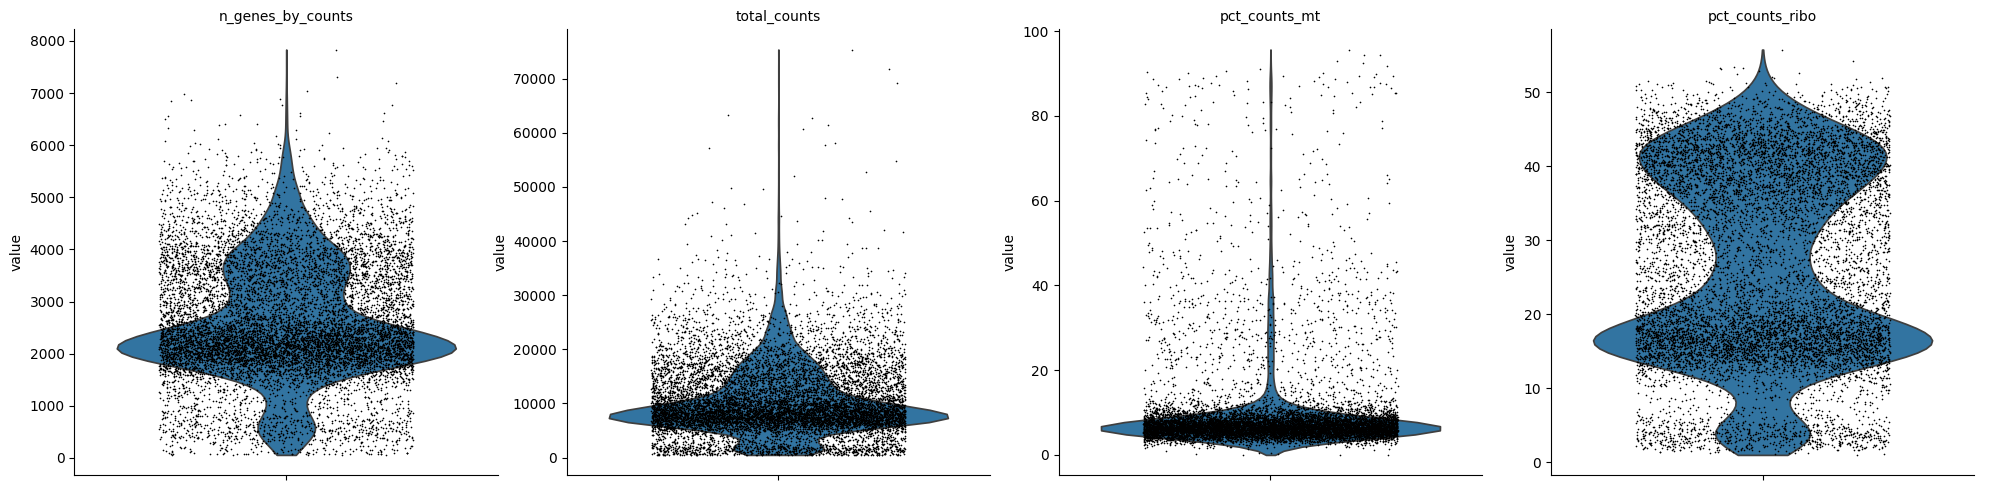

In [6]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo"],
    jitter=0.3,
    size=1.2,
    multi_panel=True
)

In [7]:
filter_condition = (adata.obs["n_genes_by_counts"] < 5000) & (adata.obs["pct_counts_mt"] < 20)
adata = adata[filter_condition]
print(f"Filtered {(~filter_condition).sum()} cells")

Filtered 1107 cells


In [8]:
%%time
sc.pp.filter_genes(adata, min_cells=5)

CPU times: user 220 ms, sys: 132 ms, total: 352 ms
Wall time: 351 ms


In [9]:
adata

AnnData object with n_obs × n_vars = 9878 × 21121
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo'
    var: 'gene_name', 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'

## Normalize

In [10]:
%%time
sc.pp.normalize_total(
    adata,
    target_sum=1e4,
    exclude_highly_expressed=False,
    layer=None,
    inplace=True
)

CPU times: user 2.43 s, sys: 35.3 ms, total: 2.46 s
Wall time: 2.4 s


In [11]:
%%time
sc.pp.log1p(
    adata,
    base=None,
    obsm=None,
    layer=None,
    #inplace=True
)

CPU times: user 264 ms, sys: 4 ms, total: 268 ms
Wall time: 266 ms


In [12]:
%%time
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=5000,
    min_mean=0.0125,
    max_mean=3,
    min_disp=0.5,
    max_disp=np.inf,
    flavor="cell_ranger",
    n_bins=20,
    span=0.3,
    layer=None,
)

CPU times: user 630 ms, sys: 47.9 ms, total: 678 ms
Wall time: 677 ms


## Clustering

In [13]:
%%time
pairs = list(product(
    range(3),
    ["covariance_eigh", "arpack", "randomized"],
))
for rs, solver in pairs:
    sc.tl.pca(
        adata,
        n_comps=50,
        zero_center=True,
        svd_solver=solver,
        random_state=rs,
        use_highly_variable=True,
        chunked=False,
        layer=None,
        key_added=f"X_pca_{solver}_{rs}",
)

adata.obsm["X_pca"] = adata.obsm["X_pca_covariance_eigh_0"]

CPU times: user 2min 43s, sys: 1.28 s, total: 2min 45s
Wall time: 42.3 s


In [14]:
adata

AnnData object with n_obs × n_vars = 9878 × 21121
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo'
    var: 'gene_name', 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'X_pca_covariance_eigh_0', 'X_pca_arpack_0', 'X_pca_randomized_0', 'X_pca_covariance_eigh_1', 'X_pca_arpack_1', 'X_pca_randomized_1', 'X_pca_covariance_eigh_2', 'X_pca_arpack_2', 'X_pca_randomized_2'
    obsm: 'X_pca_covariance_eigh_0', 'X_pca_arpack_0', 'X_pca_randomized_0', 'X_pca_covariance_eigh_1', 'X_pca_a

In [15]:
%%time
pairs = list(product(
    range(3),
    ["sklearn", "pynndescent"],
))

for rs, transformer in pairs:
    sc.pp.neighbors(
        adata,
        n_neighbors=15,
        n_pcs=50,
        #algorithm="brute",
        metric="euclidean",
        transformer=transformer,
        method="umap",
        use_rep="X_pca",
        random_state=rs,
        knn=True,
        key_added=f"neighbors{rs}_{transformer}",
    )

CPU times: user 36.2 s, sys: 2.08 s, total: 38.3 s
Wall time: 34.9 s


In [16]:
%%time
sc.tl.leiden(
    adata,
    resolution=1.0,
    random_state=4,
    #theta=1.0,
    adjacency=None,
    directed=None,
    n_iterations=100,
    use_weights=True,
    partition_type=None,
    neighbors_key="neighbors0_sklearn",
    flavor="igraph",
    key_added="leiden_igraph",
    objective_function="modularity",
    beta=1.0
    #use_dask=False
)

CPU times: user 3.41 s, sys: 7.95 ms, total: 3.42 s
Wall time: 3.42 s


In [17]:
%%time
sc.tl.leiden(
    adata,
    resolution=1.0,
    random_state=4,
    #theta=1.0,
    adjacency=None,
    directed=None,
    n_iterations=-1,
    use_weights=True,
    partition_type=None,
    neighbors_key="neighbors0_sklearn",
    flavor="leidenalg",
    key_added="leiden_leidenalg",
    #use_dask=False
)

CPU times: user 2.57 s, sys: 12 ms, total: 2.58 s
Wall time: 2.58 s


In [18]:
%%time
sc.tl.umap(
    adata,
    min_dist=0.5,
    spread=1.0,
    n_components=2,
    maxiter=100,
    alpha=1.0,
    negative_sample_rate=5,
    init_pos="spectral",
    random_state=4,
    neighbors_key="neighbors0_sklearn",
)

CPU times: user 4.43 s, sys: 8.28 ms, total: 4.44 s
Wall time: 2.41 s


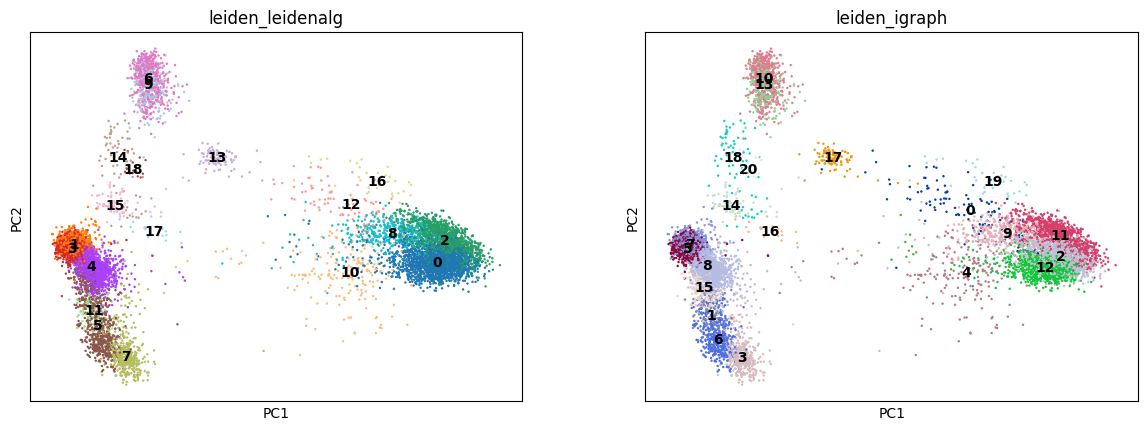

CPU times: user 186 ms, sys: 35 μs, total: 186 ms
Wall time: 185 ms


In [19]:
%%time
sc.pl.pca(adata, color=["leiden_leidenalg", "leiden_igraph"], legend_loc="on data")

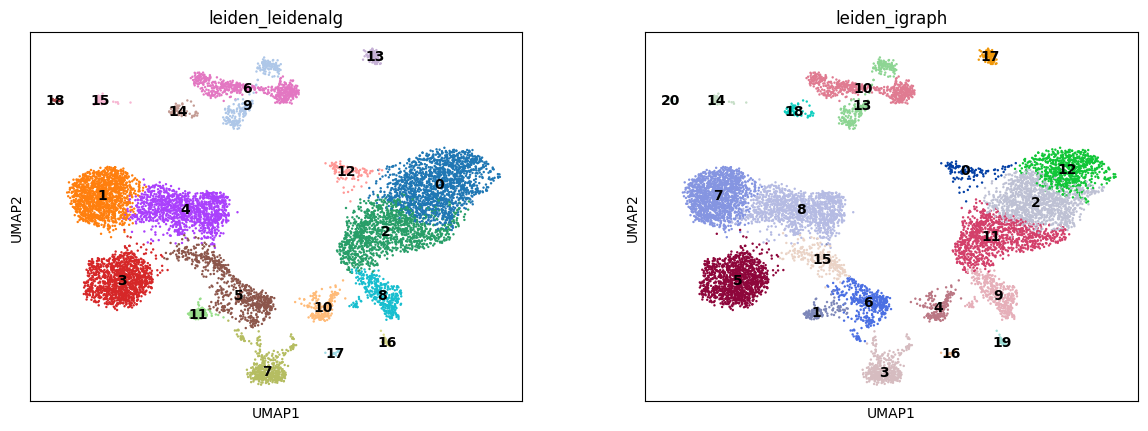

CPU times: user 169 ms, sys: 4.02 ms, total: 173 ms
Wall time: 172 ms


In [20]:
%%time
sc.pl.umap(adata, color=["leiden_leidenalg", "leiden_igraph"], legend_loc="on data")

# Save results


In [21]:
os.makedirs("results", exist_ok=True)
adata.write(
    os.path.join("results", "pbmc10k_scanpy.h5ad"),
)

np.save(
    os.path.join("results", "pbmc10k_scanpy_pca_embedding.npy"),
    adata.obsm["X_pca"],
)

sparse.save_npz(
    os.path.join("results", "pbmc10k_scanpy_distances.npz"),
    adata.obsp["neighbors0_sklearn_distances"],
)

sparse.save_npz(
    os.path.join("results", "pbmc10k_scanpy_connectivities.npz"),
    adata.obsp["neighbors0_sklearn_connectivities"],
)